Regularization

Ridge, l2 norm, parameters to unity\
Lasso, l1 norm, parameters to zero\
Elastic Net, linear comb of ridge e lasso

Gaussian Process, givrdes also errors on prediction data, works poor with big data problem



<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
/var/folders/df/8kzdlh4s5fb1h6n2cfc7y5fw0000gn/T/ipykernel_17857/3990865332.py:7: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


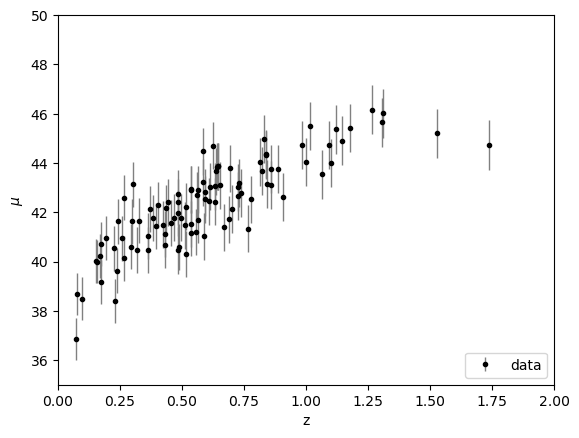

In [1]:
from astroML.datasets import generate_mu_z
import matplotlib.pyplot as plt
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) ###YOU CAN'T CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)

<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
/var/folders/df/8kzdlh4s5fb1h6n2cfc7y5fw0000gn/T/ipykernel_17857/3005725865.py:19: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


(35.0, 50.0)

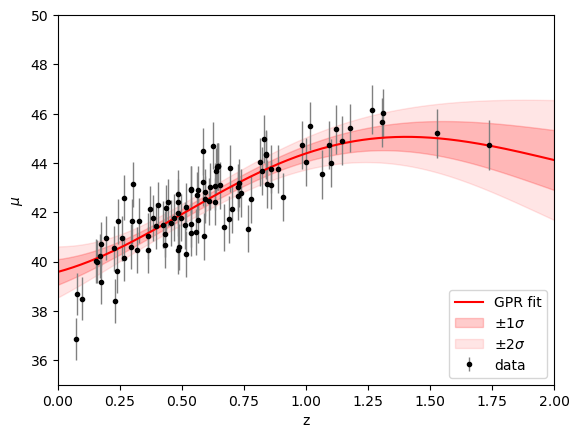

In [15]:
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
from scipy.optimize import fmin_cobyla
import numpy as np

#The key ingredient in getting a good GPR fit is the choice of the kernel and its parameters.
#Gaussian process can be completely specified by its mean and covariance function.

kernel = kernels.RBF()
gpr = GaussianProcessRegressor(kernel=kernel, alpha=dmu**2, normalize_y=True)
gpr.fit(z_sample[:, None], mu_sample)
z_fit = np.linspace(0, 2, 1000)
mu_fit, dmu_fit = gpr.predict(z_fit[:, None], return_std=True)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(z_fit, mu_fit, '-r', label='GPR fit')
plt.fill_between(z_fit, mu_fit - dmu_fit, mu_fit + dmu_fit, color='r', alpha=0.2, label=r'$\pm 1\sigma$')
plt.fill_between(z_fit, mu_fit - 2*dmu_fit, mu_fit + 2*dmu_fit, color='r', alpha=0.1, label=r'$\pm 2\sigma$')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)


He says don't trust the internal optimizer, we should really validate through cross validating the bandwidth. 